# The effect of the number of summed EDX frames

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils_EDX import *
import numpy as np
import hyperspy.api as hs
import os
import matplotlib.pyplot as plt
import copy
from skimage.metrics import peak_signal_noise_ratio as psnr
from importlib import reload
from EDX import *
from datetime import datetime
%load_ext autoreload
%autoreload 2

#### Load EMD-EDX dataset and preprocess for different numbers of frames

In [ ]:
# load data
file_path = "../data/EMD/EDXdataset.emd"

# Create results folder with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_dir = f"./results/{timestamp}"
os.makedirs(results_dir, exist_ok=True)

# load and save the 100 frame NPS
edx_ref, haadf_ref, xray_energies = load_EDX(file_path, first_frame=0, last_frame=100, sum_frames=True)
tile_ref = EM_EDX(haadf_ref, edx_ref, xray_energies)
tile_ref.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
tile_ref.apply("binning", parameters={"dim": (1024, 1024, 250)})
tile_ref.apply("MeanFilterEDX", parameters={"kernel_size": 3})

edx_ref = tile_ref.EDX
haadf_ref = tile_ref.haadf
nps_ref = tile_ref.FalseColor()

# Initialize arrays to store metrics
sad_values = []
psnr_nps_values = []
psnr_haadf_values = []

# loop over last frame
for i in range(1, 101):
    edx, haadf, xray_energies = load_EDX(file_path, first_frame=0, last_frame=i, sum_frames=True, haadf_last_frame=i)
    tile = EM_EDX(haadf, edx, xray_energies)
    tile.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
    tile.apply("binning", parameters={"dim": (1024, 1024, 250)})
    tile.apply("MeanFilterEDX", parameters={"kernel_size": 3})
    edx = tile.EDX
    haadf = tile.haadf
    nps = tile.FalseColor()


    # keep a running sum of HAADF images
    if i == 1:
        haadf_sum = haadf.copy().astype(float)
    else:
        haadf_sum += haadf
    
    # Compute SAD map (per-pixel spectral angle)
    sad_map = SAD(edx_ref, edx)
    sad_mean = np.mean(sad_map)  
    sad_values.append(sad_mean)
    
    # Compute PSNR between NPS_ref and NPS (same as before)
    psnr_nps = psnr(nps_ref, nps, data_range=1.0 if nps_ref.max() <= 1 else 255)
    psnr_nps_values.append(psnr_nps)
    
    # Compute PSNR between HAADF_ref and the running-sum version
    moving_sum_norm = haadf_sum / np.max(haadf_sum)
    psnr_haadf = psnr(haadf_ref / np.max(haadf_ref), moving_sum_norm, data_range=1.0)
    psnr_haadf_values.append(psnr_haadf)
    
    # --- Plot results ---
    f, ax = plt.subplots(2, 3, figsize=(15, 10))
    
    # Row 1
    ax[0][0].imshow(nps_ref)
    ax[0][0].set_title("Reference NPS")
    
    ax[0][1].imshow(nps)
    ax[0][1].set_title("Current NPS")
    
    im_sad = ax[0][2].imshow(sad_map, cmap="jet") ## vmin=0, vmax=np.pi
    ax[0][2].set_title("SAD Map (radians)")
    cbar = f.colorbar(im_sad, ax=ax[0][2], fraction=0.046, pad=0.04)
    cbar.set_label("Spectral Angle (rad)")
    # Remove ticks and tick labels
    cbar.set_ticks([])
    cbar.ax.tick_params(size=0)

    
    # Row 2
    ax[1][0].imshow(1 - haadf_ref, cmap='gray')
    ax[1][0].set_title("Reference HAADF")
    
    ax[1][1].imshow(1 - haadf, cmap='gray')
    ax[1][1].set_title("Current HAADF")
    
    ax[1][2].imshow(1 - moving_sum_norm, cmap='gray')
    ax[1][2].set_title(f"Moving Sum (Frame {i})")
    
    # Title and layout
    f.suptitle(
        f"Frame {i} | SAD(mean)={sad_mean:.4f} rad | PSNR(NPS)={psnr_nps:.2f} dB | PSNR(HAADF_sum)={psnr_haadf:.2f} dB",
        fontsize=12
    )
    f.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    save_path = os.path.join(results_dir, f"comparison_{i:03d}.png")
    f.savefig(save_path, dpi=150)
    plt.close(f)


# Save metrics for later plotting
np.savez(
    os.path.join(results_dir, "metrics.npz"),
    sad=np.array(sad_values),
    psnr_nps=np.array(psnr_nps_values),
    psnr_haadf=np.array(psnr_haadf_values)
)

print(f"Done! Saved results and metrics in {results_dir}")

In [21]:
# Save metrics for later plotting
np.savez(
    os.path.join(results_dir, "metrics.npz"),
    sad=np.array(sad_values),
    psnr_nps=np.array(psnr_nps_values),
    psnr_haadf=np.array(psnr_haadf_values)
)


### Plot metrics

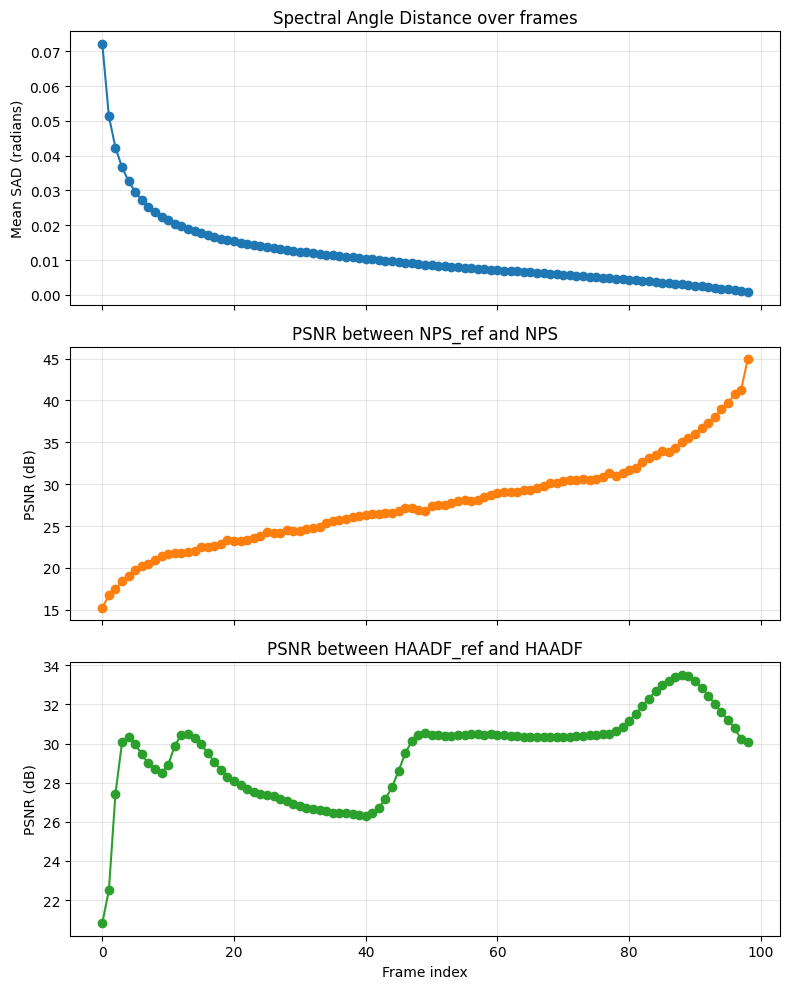

In [23]:
# Load
data = np.load(os.path.join(results_dir, "metrics.npz"))
sad = data["sad"]
psnr_nps = data["psnr_nps"]
psnr_haadf = data["psnr_haadf"]

# plot
fig, ax = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

ax[0].plot(sad, "-o")
ax[0].set_ylabel("Mean SAD (radians)")
ax[0].set_title("Spectral Angle Distance over frames")
ax[0].grid(True, alpha=0.3)

ax[1].plot(psnr_nps, "-o", color="tab:orange")
ax[1].set_ylabel("PSNR (dB)")
ax[1].set_title("PSNR between NPS_ref and NPS")
ax[1].grid(True, alpha=0.3)

ax[2].plot(psnr_haadf, "-o", color="tab:green")
ax[2].set_ylabel("PSNR (dB)")
ax[2].set_xlabel("Frame index")
ax[2].set_title("PSNR between HAADF_ref and HAADF")
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()